# prédisent le taux d'embauche des étudiants

C:\Users\USER\AppData\Local\Temp\ipykernel_22420\4234238870.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, pyodbc.connect(conn_str))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(



  Random Forest Regressor
 MSE : 0.0002
 RMSE : 0.0136
 R² : 0.6806

  XGBoost Regressor
 MSE : 0.0003
 RMSE : 0.0168
 R² : 0.5133

  Régression Linéaire
 MSE : 0.0005
 RMSE : 0.0233
 R² : 0.0650

 Top 10 universités (par prédiction XGBoost) :
                   Université  Taux Réel  RF_Prédit  XGB_Prédit  LinReg_Prédit
10       Université de Bamako       0.82     0.8392    0.843641       0.822001
6           Université d'Oran       0.83     0.8364    0.840909       0.828760
3     University of Cape Town       0.85     0.8333    0.834997       0.852461
2         University of Ghana       0.85     0.8208    0.827352       0.824880
11   Université Moulay Ismail       0.80     0.8081    0.822054       0.845073
7        University of Ibadan       0.83     0.8265    0.815099       0.830286
12       Université de Niamey       0.83     0.8222    0.813804       0.820721
13     University of Khartoum       0.81     0.8112    0.813644       0.811221
14     Addis Ababa University       0.81    

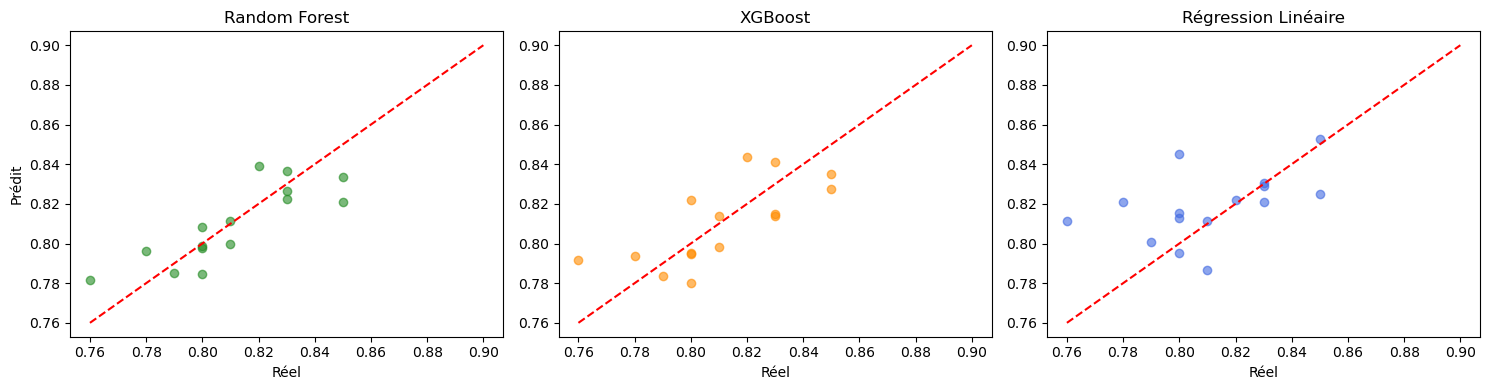

In [1]:
import pyodbc
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import xgboost as xgb

# Connexion à la base SQL Server
server = 'LAPTOP-BJE2TQGI\\KK'
database = 'add'
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

# Requête SQL
query = """
SELECT [University_Name], [Country], [Specialties], [Student_Count], 
       [Successful_Students], [Success_Rate__Taux_de_Reussite], [Employment_Rate__Taux_d_Embauche]
FROM [add].[dbo].[Dim_University]
"""

# Charger les données
df = pd.read_sql(query, pyodbc.connect(conn_str))

# Nettoyage
df['Success_Rate__Taux_de_Reussite'] = df['Success_Rate__Taux_de_Reussite'].str.rstrip('%').astype(float) / 100
df['Employment_Rate__Taux_d_Embauche'] = df['Employment_Rate__Taux_d_Embauche'].str.rstrip('%').astype(float) / 100
df.dropna(inplace=True)

# Définir X et y
X = df[['Country', 'Specialties', 'Student_Count', 'Successful_Students', 'Success_Rate__Taux_de_Reussite']]
y = df['Employment_Rate__Taux_d_Embauche']

# Encodage One-Hot
categorical_cols = ['Country', 'Specialties']
encoder = OneHotEncoder(sparse=False, drop='first')
encoded = encoder.fit_transform(X[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

X_encoded = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), encoded_df], axis=1)

# Split des données
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
uni_test = df.loc[X_test.index, 'University_Name']

# Fonction pour afficher les performances
def eval_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n {name}")
    print(f" MSE : {mse:.4f}")
    print(f" RMSE : {rmse:.4f}")
    print(f" R² : {r2:.4f}")
    return mse, rmse, r2

# ------------------  1. Random Forest ------------------
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
eval_model(" Random Forest Regressor", y_test, rf_pred)

# ------------------  2. XGBoost ------------------
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
eval_model(" XGBoost Regressor", y_test, xgb_pred)

# ------------------  3. Régression Linéaire ------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
eval_model(" Régression Linéaire", y_test, lr_pred)

# ------------------ Affichage des prédictions par université ------------------
results_df = pd.DataFrame({
    'Université': uni_test.values,
    'Taux Réel': y_test.values,
    'RF_Prédit': rf_pred,
    'XGB_Prédit': xgb_pred,
    'LinReg_Prédit': lr_pred
})

print("\n Top 10 universités (par prédiction XGBoost) :")
print(results_df.sort_values(by="XGB_Prédit", ascending=False).head(10))

# ------------------ Visualisation ------------------
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_test, rf_pred, alpha=0.6, c='forestgreen')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Random Forest")
plt.xlabel("Réel")
plt.ylabel("Prédit")

plt.subplot(1, 3, 2)
plt.scatter(y_test, xgb_pred, alpha=0.6, c='darkorange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("XGBoost")
plt.xlabel("Réel")

plt.subplot(1, 3, 3)
plt.scatter(y_test, lr_pred, alpha=0.6, c='royalblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title("Régression Linéaire")
plt.xlabel("Réel")

plt.tight_layout()
plt.show()

# Regression Liniaire(RandomForest)

C:\Users\USER\AppData\Local\Temp\ipykernel_22420\1510455821.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, pyodbc.connect(conn_str))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(



  Random Forest Regressor
 MSE : 0.0002
 RMSE : 0.0136
 R² : 0.6806

 Résultats de la Régression Random Forest :
                  Université  Taux Réel  RF_Prédit
10      Université de Bamako       0.82     0.8392
6          Université d'Oran       0.83     0.8364
3    University of Cape Town       0.85     0.8333
7       University of Ibadan       0.83     0.8265
12      Université de Niamey       0.83     0.8222
2        University of Ghana       0.85     0.8208
13    University of Khartoum       0.81     0.8112
11  Université Moulay Ismail       0.80     0.8081
14    Addis Ababa University       0.81     0.7997
8       Université de Luanda       0.80     0.7985


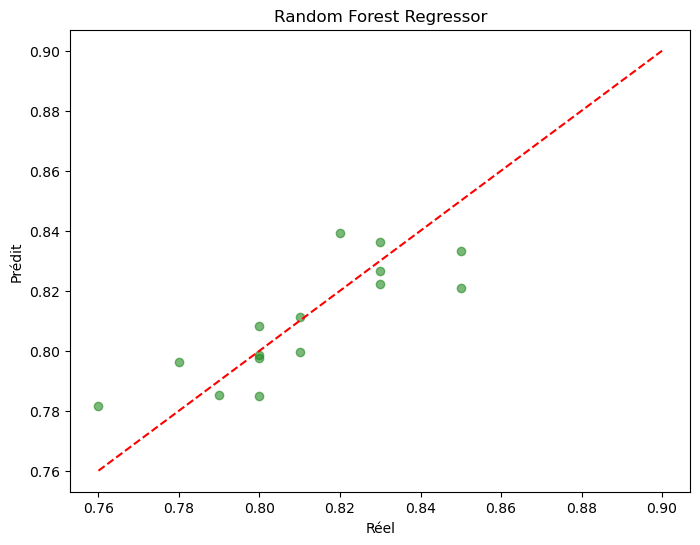

In [3]:
# Importation des bibliothèques nécessaires
import pyodbc  # Bibliothèque pour se connecter à une base de données SQL Server
import pandas as pd  # Bibliothèque pour la manipulation de données sous forme de DataFrame
import numpy as np  # Bibliothèque pour les calculs numériques
from sklearn.model_selection import train_test_split  # Pour diviser les données en ensembles d'entraînement et de test
from sklearn.preprocessing import OneHotEncoder  # Pour encoder les variables catégorielles en variables numériques
from sklearn.ensemble import RandomForestRegressor  # Modèle de régression utilisant la forêt aléatoire
from sklearn.metrics import mean_squared_error, r2_score  # Métriques pour évaluer les performances du modèle
import matplotlib.pyplot as plt  # Bibliothèque pour la visualisation des résultats

# Définition des paramètres de connexion à la base de données SQL Server
server = 'LAPTOP-BJE2TQGI\\KK'  # Nom du serveur SQL
database = 'add'  # Nom de la base de données
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'  # Chaîne de connexion

# Requête SQL pour extraire les données de la table Dim_University
query = """
SELECT [University_Name], [Country], [Specialties], [Student_Count],
       [Successful_Students], [Success_Rate__Taux_de_Reussite], [Employment_Rate__Taux_d_Embauche]
FROM [add].[dbo].[Dim_University]
"""

# Chargement des données de la base SQL dans un DataFrame pandas
df = pd.read_sql(query, pyodbc.connect(conn_str))

# Nettoyage des colonnes de taux en supprimant le symbole '%' et en convertissant en décimale
df['Success_Rate__Taux_de_Reussite'] = df['Success_Rate__Taux_de_Reussite'].str.rstrip('%').astype(float) / 100  # Conversion du taux de réussite
df['Employment_Rate__Taux_d_Embauche'] = df['Employment_Rate__Taux_d_Embauche'].str.rstrip('%').astype(float) / 100  # Conversion du taux d'embauche

# Suppression des lignes contenant des valeurs manquantes
df.dropna(inplace=True)

# Séparation des variables explicatives (X) et de la variable cible (y)
X = df[['Country', 'Specialties', 'Student_Count', 'Successful_Students', 'Success_Rate__Taux_de_Reussite']]  # Variables explicatives
y = df['Employment_Rate__Taux_d_Embauche']  # Variable cible à prédire

# Définition des colonnes catégorielles à encoder
categorical_cols = ['Country', 'Specialties']

# Initialisation de l'encodeur One-Hot pour transformer les colonnes catégorielles
encoder = OneHotEncoder(sparse=False, drop='first')  # sparse=False pour obtenir un tableau dense ; drop='first' pour éviter la redondance

# Application de l'encodage sur les colonnes catégorielles
encoded = encoder.fit_transform(X[categorical_cols])

# Création d'un DataFrame avec les colonnes encodées
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

# Fusion des colonnes numériques et encodées pour créer le DataFrame final
X_encoded = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), encoded_df], axis=1)

# Division du dataset en ensemble d'entraînement (80%) et ensemble de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Récupération des noms des universités correspondant aux indices de test pour les afficher avec les résultats
uni_test = df.loc[X_test.index, 'University_Name']

# Définition d'une fonction pour évaluer les performances d'un modèle
def eval_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)  # Calcul de l'erreur quadratique moyenne
    rmse = np.sqrt(mse)  # Racine carrée de l'erreur quadratique moyenne
    r2 = r2_score(y_true, y_pred)  # Coefficient de détermination R²
    print(f"\n {name}")
    print(f" MSE : {mse:.4f}")
    print(f" RMSE : {rmse:.4f}")
    print(f" R² : {r2:.4f}")

# Création d'un modèle Random Forest avec 100 arbres
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Entraînement du modèle sur l'ensemble d'entraînement
rf_model.fit(X_train, y_train)

# Prédiction sur l'ensemble de test
rf_pred = rf_model.predict(X_test)

# Évaluation des performances du modèle
eval_model(" Random Forest Regressor", y_test, rf_pred)

# Création d’un DataFrame pour comparer les taux réels et les taux prédits
results_df = pd.DataFrame({
    'Université': uni_test.values,  # Nom de l'université
    'Taux Réel': y_test.values,  # Taux d'embauche réel
    'RF_Prédit': rf_pred  # Taux d'embauche prédit
})

# Affichage des 10 universités ayant les taux prédits les plus élevés
print("\n Résultats de la Régression Random Forest :")
print(results_df.sort_values(by="RF_Prédit", ascending=False).head(10))

# Visualisation de la performance du modèle : Réel vs Prédit
plt.figure(figsize=(8, 6))  # Définir la taille de la figure
plt.scatter(y_test, rf_pred, alpha=0.6, c='forestgreen')  # Nuage de points : prédictions vs valeurs réelles
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Ligne de référence diagonale (réel = prédit)
plt.title("Random Forest Regressor")  # Titre du graphique
plt.xlabel("Réel")  # Étiquette de l'axe x
plt.ylabel("Prédit")  # Étiquette de l'axe y
plt.show()  # Affichage du graphique


# Regression Liniaire(XGboost)

C:\Users\USER\AppData\Local\Temp\ipykernel_13904\4292925721.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, pyodbc.connect(conn_str))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(



  XGBoost Regressor
 MSE : 0.0003
 RMSE : 0.0168
 R² : 0.5133

 Résultats de la Régression XGBoost :
                   Université  Taux Réel  XGB_Prédit
10       Université de Bamako       0.82    0.843641
6           Université d'Oran       0.83    0.840909
3     University of Cape Town       0.85    0.834997
2         University of Ghana       0.85    0.827352
11   Université Moulay Ismail       0.80    0.822054
7        University of Ibadan       0.83    0.815099
12       Université de Niamey       0.83    0.813804
13     University of Khartoum       0.81    0.813644
14     Addis Ababa University       0.81    0.798379
4   Université de Ouagadougou       0.80    0.795066


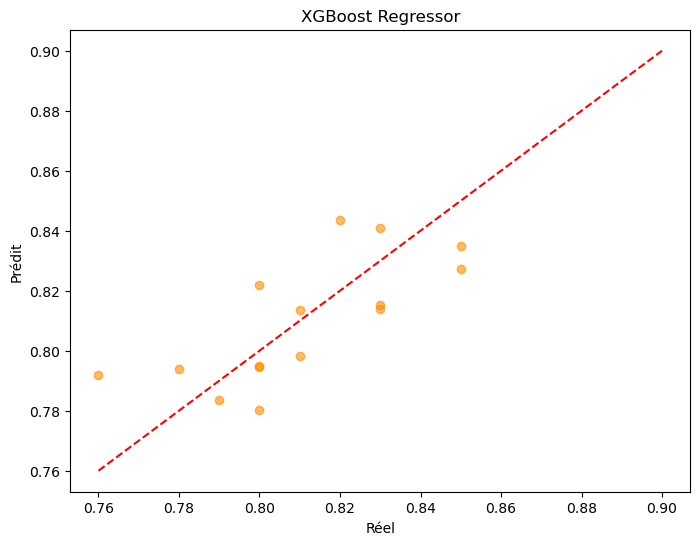

In [5]:
# Importation des bibliothèques nécessaires
import pyodbc  # Pour se connecter à une base de données SQL Server
import pandas as pd  # Pour manipuler les données sous forme de DataFrame
import numpy as np  # Pour les opérations numériques (ex: racine carrée)
from sklearn.model_selection import train_test_split  # Pour diviser les données en ensemble d'entraînement et de test
from sklearn.preprocessing import OneHotEncoder  # Pour encoder les variables catégorielles
from sklearn.metrics import mean_squared_error, r2_score  # Pour évaluer les performances du modèle
import xgboost as xgb  # Modèle de régression XGBoost
import matplotlib.pyplot as plt  # Pour visualiser les résultats

# Connexion au serveur SQL Server
server = 'LAPTOP-BJE2TQGI\\KK'  # Nom du serveur
database = 'add'  # Nom de la base de données
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'  # Chaîne de connexion

# Requête SQL pour récupérer les données
query = """  
SELECT [University_Name], [Country], [Specialties], [Student_Count],   
       [Successful_Students], [Success_Rate__Taux_de_Reussite], [Employment_Rate__Taux_d_Embauche]  
FROM [add].[dbo].[Dim_University]  
"""  

# Chargement des données dans un DataFrame à partir de la base SQL
df = pd.read_sql(query, pyodbc.connect(conn_str))  

# Nettoyage des données
df['Success_Rate__Taux_de_Reussite'] = df['Success_Rate__Taux_de_Reussite'].str.rstrip('%').astype(float) / 100  # Conversion du taux de réussite de chaîne vers float
df['Employment_Rate__Taux_d_Embauche'] = df['Employment_Rate__Taux_d_Embauche'].str.rstrip('%').astype(float) / 100  # Idem pour le taux d’embauche
df.dropna(inplace=True)  # Suppression des lignes contenant des valeurs manquantes

# Définition des variables indépendantes (X) et de la variable cible (y)
X = df[['Country', 'Specialties', 'Student_Count', 'Successful_Students', 'Success_Rate__Taux_de_Reussite']]  # Variables explicatives
y = df['Employment_Rate__Taux_d_Embauche']  # Variable à prédire

# Encodage des variables catégorielles
categorical_cols = ['Country', 'Specialties']  # Colonnes contenant des catégories à encoder
encoder = OneHotEncoder(sparse=False, drop='first')  # Instanciation de l'encodeur One-Hot en supprimant la première catégorie pour éviter la colinéarité
encoded = encoder.fit_transform(X[categorical_cols])  # Application de l'encodage sur les colonnes catégorielles
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))  # Conversion en DataFrame avec noms de colonnes

# Fusion des données encodées avec les autres variables numériques
X_encoded = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), encoded_df], axis=1)  

# Séparation des données en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)  # 80% train / 20% test
uni_test = df.loc[X_test.index, 'University_Name']  # Récupération des noms d’université correspondants à X_test pour l’affichage des résultats

# Fonction pour évaluer les performances du modèle
def eval_model(name, y_true, y_pred):  
    mse = mean_squared_error(y_true, y_pred)  # Erreur quadratique moyenne
    rmse = np.sqrt(mse)  # Racine de l’erreur quadratique moyenne
    r2 = r2_score(y_true, y_pred)  # Coefficient de détermination (R²)
    print(f"\n {name}")  
    print(f" MSE : {mse:.4f}")  
    print(f" RMSE : {rmse:.4f}")  
    print(f" R² : {r2:.4f}")  

# Modélisation avec XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42)  # Création du modèle XGBoost avec 100 arbres
xgb_model.fit(X_train, y_train)  # Entraînement du modèle sur les données d’entraînement
xgb_pred = xgb_model.predict(X_test)  # Prédiction sur les données de test

# Évaluation du modèle
eval_model(" XGBoost Regressor", y_test, xgb_pred)  # Affichage des métriques de performance

# Création d’un DataFrame contenant les résultats
results_df = pd.DataFrame({  
    'Université': uni_test.values,  # Nom des universités
    'Taux Réel': y_test.values,  # Valeur réelle du taux d’embauche
    'XGB_Prédit': xgb_pred  # Valeur prédite par le modèle
})  

# Affichage des 10 universités avec les meilleurs taux prédits
print("\n Résultats de la Régression XGBoost :")  
print(results_df.sort_values(by="XGB_Prédit", ascending=False).head(10))  # Affiche les 10 universités avec les meilleurs taux d’embauche prédits

# Visualisation des résultats
plt.figure(figsize=(8, 6))  # Définition de la taille du graphique
plt.scatter(y_test, xgb_pred, alpha=0.6, c='darkorange')  # Nuage de points des vraies vs prédictions
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Ligne de référence diagonale (parfaite égalité)
plt.title("XGBoost Regressor")  # Titre du graphique
plt.xlabel("Réel")  # Axe des X
plt.ylabel("Prédit")  # Axe des Y
plt.show()  # Affichage du graphique


# RegressionLiniaire (Regression Liniaire)

C:\Users\USER\AppData\Local\Temp\ipykernel_22420\2286273692.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, pyodbc.connect(conn_str))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(



 Régression Linéaire
 MSE : 0.0003
 RMSE : 0.0166
 R² : 0.5265

 Résultats de la Régression Linéaire :
                  Université  Taux Réel  LinReg_Prédit
3    University of Cape Town       0.85       0.855700
11  Université Moulay Ismail       0.80       0.838917
6          Université d'Oran       0.83       0.829193
2        University of Ghana       0.85       0.829113
12      Université de Niamey       0.83       0.822774
10      Université de Bamako       0.82       0.818235
8       Université de Luanda       0.80       0.815591
13    University of Khartoum       0.81       0.815073
7       University of Ibadan       0.83       0.810371
9     Université de Cap-Vert       0.78       0.808664


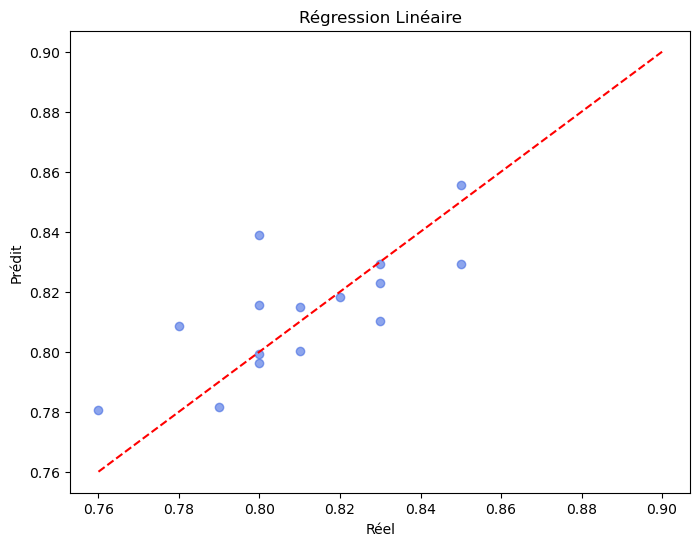

In [6]:
import pyodbc  # Pour se connecter à une base de données SQL Server
import pandas as pd  # Pour la manipulation de données sous forme de DataFrame
import numpy as np  # Pour les opérations mathématiques et les tableaux
from sklearn.model_selection import train_test_split  # Pour diviser les données en ensembles d'entraînement et de test
from sklearn.preprocessing import OneHotEncoder, StandardScaler  # Pour l'encodage des variables catégorielles et la normalisation
from sklearn.linear_model import LinearRegression  # Pour appliquer un modèle de régression linéaire
from sklearn.metrics import mean_squared_error, r2_score  # Pour évaluer les performances du modèle
import matplotlib.pyplot as plt  # Pour visualiser les résultats

# Connexion à la base de données SQL Server
server = 'LAPTOP-BJE2TQGI\\KK'  # Nom du serveur SQL
database = 'add'  # Nom de la base de données
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'  # Chaîne de connexion

# Requête SQL pour extraire les données nécessaires
query = """
SELECT [University_Name], [Country], [Specialties], [Student_Count],  
       [Successful_Students], [Success_Rate__Taux_de_Reussite], [Employment_Rate__Taux_d_Embauche]
FROM [add].[dbo].[Dim_University]
"""

# Lecture des données SQL dans un DataFrame pandas
df = pd.read_sql(query, pyodbc.connect(conn_str))

# Nettoyage des données : suppression du caractère '%' et conversion en float (ex. 85% → 0.85)
df['Success_Rate__Taux_de_Reussite'] = df['Success_Rate__Taux_de_Reussite'].str.rstrip('%').astype(float) / 100
df['Employment_Rate__Taux_d_Embauche'] = df['Employment_Rate__Taux_d_Embauche'].str.rstrip('%').astype(float) / 100

# Suppression des lignes contenant des valeurs manquantes
df.dropna(inplace=True)

# Définition des variables indépendantes (X) et de la variable cible (y)
X = df[['Country', 'Specialties', 'Student_Count', 'Successful_Students', 'Success_Rate__Taux_de_Reussite']]
y = df['Employment_Rate__Taux_d_Embauche']

# Liste des colonnes catégorielles à encoder
categorical_cols = ['Country', 'Specialties']

# Création d'un encodeur One-Hot pour convertir les variables catégorielles en variables binaires
encoder = OneHotEncoder(sparse=False, drop='first')  # drop='first' évite la redondance (dummy variable trap)
encoded = encoder.fit_transform(X[categorical_cols])  # Encodage des colonnes

# Création d'un DataFrame pour les colonnes encodées
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

# Fusion des variables numériques avec les variables encodées
X_encoded = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), encoded_df], axis=1)

# Normalisation (centrage-réduction) des colonnes numériques
scaler = StandardScaler()
X_encoded[['Student_Count', 'Successful_Students', 'Success_Rate__Taux_de_Reussite']] = scaler.fit_transform(
    X_encoded[['Student_Count', 'Successful_Students', 'Success_Rate__Taux_de_Reussite']])

# Séparation des données en ensemble d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Sauvegarde des noms d'universités correspondant à l'ensemble de test
uni_test = df.loc[X_test.index, 'University_Name']

# Fonction d’évaluation du modèle : calcule les erreurs (MSE, RMSE) et le coefficient de détermination (R²)
def eval_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"\n {name}")
    print(f" MSE : {mse:.4f}")
    print(f" RMSE : {rmse:.4f}")
    print(f" R² : {r2:.4f}")

# Création et entraînement du modèle de régression linéaire
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prédiction sur l’ensemble de test
lr_pred = lr_model.predict(X_test)

# Évaluation des performances de la régression linéaire
eval_model("Régression Linéaire", y_test, lr_pred)

# Création d’un DataFrame pour comparer les prédictions et les valeurs réelles
results_df = pd.DataFrame({
    'Université': uni_test.values,
    'Taux Réel': y_test.values,
    'LinReg_Prédit': lr_pred
})

# Affichage des 10 universités avec les meilleurs taux d'embauche prédits
print("\n Résultats de la Régression Linéaire :")
print(results_df.sort_values(by="LinReg_Prédit", ascending=False).head(10))

# Visualisation : nuage de points entre les valeurs réelles et les prédictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_pred, alpha=0.6, c='royalblue')  # Points (réel vs prédit)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Ligne idéale (prédit = réel)
plt.title("Régression Linéaire")
plt.xlabel("Réel")
plt.ylabel("Prédit")
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_13904\1101734254.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, pyodbc.connect(conn_str))
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Comparaison des modèles :
               Model       MSE      RMSE        R²
0      Random Forest  0.000185  0.013606  0.680597
1            XGBoost  0.000282  0.016794  0.513329
2  Linear Regression  0.000274  0.016566  0.526470


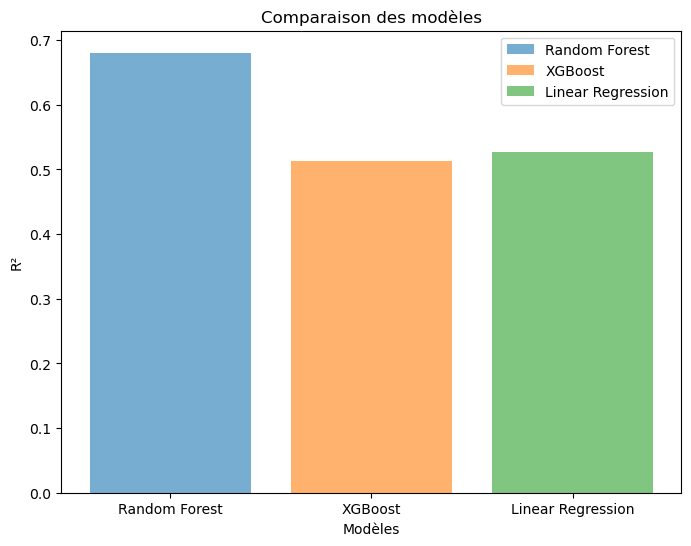

In [17]:
import pyodbc
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Connexion à la base SQL Server
server = 'LAPTOP-BJE2TQGI\\KK'
database = 'add'
conn_str = f'DRIVER={{SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes;'

# Requête SQL
query = """
SELECT [University_Name], [Country], [Specialties], [Student_Count],
       [Successful_Students], [Success_Rate__Taux_de_Reussite], [Employment_Rate__Taux_d_Embauche]
FROM [add].[dbo].[Dim_University]
"""

# Charger les données
df = pd.read_sql(query, pyodbc.connect(conn_str))

# Nettoyage des données
df['Success_Rate__Taux_de_Reussite'] = df['Success_Rate__Taux_de_Reussite'].str.rstrip('%').astype(float) / 100
df['Employment_Rate__Taux_d_Embauche'] = df['Employment_Rate__Taux_d_Embauche'].str.rstrip('%').astype(float) / 100
df.dropna(inplace=True)

# Définir X et y
X = df[['Country', 'Specialties', 'Student_Count', 'Successful_Students', 'Success_Rate__Taux_de_Reussite']]
y = df['Employment_Rate__Taux_d_Embauche']

# Encodage One-Hot des variables catégorielles
categorical_cols = ['Country', 'Specialties']
encoder = OneHotEncoder(sparse=False, drop='first')
encoded = encoder.fit_transform(X[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

# Combinaison des variables encodées avec les autres variables numériques
X_encoded = pd.concat([X.drop(columns=categorical_cols).reset_index(drop=True), encoded_df], axis=1)

# Normalisation des données numériques
scaler = StandardScaler()
X_encoded[['Student_Count', 'Successful_Students', 'Success_Rate__Taux_de_Reussite']] = scaler.fit_transform(X_encoded[['Student_Count', 'Successful_Students', 'Success_Rate__Taux_de_Reussite']])

# Split des données en train et test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
uni_test = df.loc[X_test.index, 'University_Name']

# Fonction d'évaluation du modèle
def eval_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "MSE": mse, "RMSE": rmse, "R²": r2}

# Création des modèles
models = [
    ("Random Forest", RandomForestRegressor(n_estimators=100, random_state=42)),
    ("XGBoost", xgb.XGBRegressor(n_estimators=100, random_state=42)),
    ("Linear Regression", LinearRegression())
]

# Évaluation des modèles
results = []
for model_name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append(eval_model(model_name, y_test, y_pred))

# Affichage des résultats
results_df = pd.DataFrame(results)
print("Comparaison des modèles :")
print(results_df)

# Visualisation des résultats
plt.figure(figsize=(8, 6))
for index, row in results_df.iterrows():
    plt.bar(row['Model'], row['R²'], label=row['Model'], alpha=0.6)

plt.title("Comparaison des modèles")
plt.xlabel("Modèles")
plt.ylabel("R²")
plt.legend()
plt.show()
